In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

# 데이터 로드
df = pd.read_excel('data.xlsx')
target_col = 'label（100nm）'

print("전체 행 수:", len(df))
print("unique payloads:", df['Payload Isosmiles'].nunique())
print("unique linkers:", df['Linker Isosmiles'].nunique())
print("라벨 분포:")
print(df[target_col].value_counts())

전체 행 수: 435
unique payloads: 71
unique linkers: 82
라벨 분포:
label（100nm）
1    281
0    154
Name: count, dtype: int64


In [4]:
# payload와 linker를 각각 Morgan fingerprint(2048bit)로 만들어서 합치기 (4096차원)
def smiles_to_fp(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    return np.array(bv), bv

# 원본 순서 유지를 위해 index 리셋
df = df.reset_index(drop=True)

payload_np, payload_bv, linker_np, linker_bv = [], [], [], []
for smi in df['Payload Isosmiles']:
    a, b = smiles_to_fp(smi)
    payload_np.append(a); payload_bv.append(b)
for smi in df['Linker Isosmiles']:
    a, b = smiles_to_fp(smi)
    linker_np.append(a); linker_bv.append(b)

df['payload_fp']  = payload_np
df['payload_bv']  = payload_bv
df['linker_fp']   = linker_np
df['linker_bv']   = linker_bv

# payload+linker fingerprint 합치기
df['combined_fp'] = df.apply(
    lambda r: np.concatenate([r['payload_fp'], r['linker_fp']]), axis=1)

# 확인
print("전체 행 수:", len(df))
print("fingerprint 실패한 행:", df['payload_fp'].isna().sum() + df['linker_fp'].isna().sum())
print("combined_fp 차원:", len(df['combined_fp'].iloc[0]))
print("target_col:", target_col)

[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerator
[12:38:04] DEPRECATION WARNING: please use MorganGenerat

ValueError: zero-dimensional arrays cannot be concatenated

In [6]:
# fingerprint 실패한 행 찾기
payload_fail = df['payload_fp'].apply(lambda x: x is None)
linker_fail  = df['linker_fp'].apply(lambda x: x is None)

print("payload fingerprint 실패:", payload_fail.sum(), "개")
print("linker fingerprint 실패:", linker_fail.sum(), "개")
print()

if payload_fail.sum() > 0:
    print("실패한 payload SMILES:")
    for s in df.loc[payload_fail, 'Payload Isosmiles'].unique():
        print(" ", s)
if linker_fail.sum() > 0:
    print("실패한 linker SMILES:")
    for s in df.loc[linker_fail, 'Linker Isosmiles'].unique():
        print(" ", s)

payload fingerprint 실패: 2 개
linker fingerprint 실패: 1 개

실패한 payload SMILES:
  NCCC1C2CO[PH](=O)(=O)OC3C(COP(=O)(O)OC1C(n1cnc4c(=O)[nH]c(N)nc41)O2)OC(n1cnc2c(N)ncnc21)C3O
실패한 linker SMILES:
  C/C(=C\CO[PH](=O)(=O)O[PH](=O)(=O)O)CC/C=C(\C)CC/C(C)=N/OCCOCCOCCNC(=O)c1cc(CO)ccc1OC1OC(C(=O)O)C(O)C(O)C1O


In [7]:
# 실패한 SMILES가 들어간 행이 총 몇 개인지 확인
bad_mask = df['payload_fp'].apply(lambda x: x is None) | df['linker_fp'].apply(lambda x: x is None)
print("제거될 행 수:", bad_mask.sum())
print("제거 후 남는 행 수:", (~bad_mask).sum())
print("제거 후 unique payloads:", df.loc[~bad_mask, 'Payload Isosmiles'].nunique())

제거될 행 수: 3
제거 후 남는 행 수: 432
제거 후 unique payloads: 70


In [8]:
# fingerprint 실패한 3개 행 제거 (기존 build_features와 동일한 처리)
bad_mask = df['payload_fp'].apply(lambda x: x is None) | df['linker_fp'].apply(lambda x: x is None)
df = df[~bad_mask].reset_index(drop=True)

# combined_fp 다시 생성 (이제 None 없으니 성공)
df['combined_fp'] = df.apply(
    lambda r: np.concatenate([r['payload_fp'], r['linker_fp']]), axis=1)

print("최종 행 수:", len(df))
print("최종 unique payloads:", df['Payload Isosmiles'].nunique())
print("combined_fp 차원:", len(df['combined_fp'].iloc[0]))
print("라벨 분포:")
print(df[target_col].value_counts())

최종 행 수: 432
최종 unique payloads: 70
combined_fp 차원: 4096
라벨 분포:
label（100nm）
1    278
0    154
Name: count, dtype: int64


In [9]:
import json
from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Master Split 생성: 모든 split을 conjugate index(정수)로 고정 ──
# df는 이미 reset_index(drop=True) 된 상태 (0~431)
idx = np.arange(len(df))
payload_col = 'Payload Isosmiles'
master = {}

# ── 1) RANDOM SPLIT (leakage 있는 대조군, 10 seeds, stratified) ──
master['random'] = []
for s in range(10):
    tr, te = train_test_split(idx, test_size=0.2, random_state=s,
                              stratify=df[target_col].values)
    master['random'].append({'seed': s,
                             'train_idx': tr.tolist(),
                             'test_idx': te.tolist()})

# ── 2) DRUG-BASED SPLIT (payload 분리, 10 seeds) ──
unique_p = df[payload_col].unique()
master['drug_based'] = []
for s in range(10):
    tr_p, te_p = train_test_split(unique_p, test_size=0.2, random_state=s)
    tr = idx[df[payload_col].isin(tr_p).values]
    te = idx[df[payload_col].isin(te_p).values]
    master['drug_based'].append({'seed': s,
                                'train_idx': tr.tolist(),
                                'test_idx': te.tolist()})

print("random splits:", len(master['random']), "seeds")
print("drug_based splits:", len(master['drug_based']), "seeds")
print()
print("random seed 0 → train:", len(master['random'][0]['train_idx']),
      "test:", len(master['random'][0]['test_idx']))
print("drug_based seed 0 → train:", len(master['drug_based'][0]['train_idx']),
      "test:", len(master['drug_based'][0]['test_idx']))

random splits: 10 seeds
drug_based splits: 10 seeds

random seed 0 → train: 345 test: 87
drug_based seed 0 → train: 387 test: 45


In [10]:
# ── 3) TANIMOTO-DISSIMILARITY HOLDOUT (가장 고립된 payload 20% 고정) ──
# 각 payload의 "다른 payload와의 최대 Tanimoto 유사도" 계산 → 가장 낮은(고립된) 것들 holdout
unique_smiles = df[payload_col].unique()

# payload별 대표 fingerprint (bit vector) 하나씩
payload_to_bv = {}
for smi in unique_smiles:
    row = df[df[payload_col] == smi].iloc[0]
    payload_to_bv[smi] = row['payload_bv']

bvs = [payload_to_bv[s] for s in unique_smiles]
max_sims = []
for i, bv in enumerate(bvs):
    others = [b for j, b in enumerate(bvs) if j != i]
    sims = DataStructs.BulkTanimotoSimilarity(bv, others)
    max_sims.append(max(sims) if sims else 0.0)

sim_df = pd.DataFrame({'payload': unique_smiles, 'max_tanimoto': max_sims})
sim_df = sim_df.sort_values('max_tanimoto').reset_index(drop=True)

n_holdout = int(len(unique_smiles) * 0.2)
holdout_payloads = set(sim_df['payload'].iloc[:n_holdout])
remaining_payloads = set(sim_df['payload'].iloc[n_holdout:])

holdout_idx   = idx[df[payload_col].isin(holdout_payloads).values]
remaining_idx = idx[df[payload_col].isin(remaining_payloads).values]

master['holdout'] = {
    'train_idx': remaining_idx.tolist(),
    'test_idx':  holdout_idx.tolist()
}

# ── 4) 5-FOLD CV (holdout의 train 부분에서, payload 단위 stratified) ──
rem_df = df.iloc[remaining_idx].reset_index(drop=True)
rem_payloads = rem_df[payload_col].unique()
payload_lab = rem_df.groupby(payload_col)[target_col].agg(
    lambda x: int(x.mean() > 0.5)).values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
master['cv_folds'] = []
for tr_pi, te_pi in skf.split(rem_payloads, payload_lab):
    tr_p = set(rem_payloads[tr_pi]); te_p = set(rem_payloads[te_pi])
    tr = remaining_idx[rem_df[payload_col].isin(tr_p).values]
    te = remaining_idx[rem_df[payload_col].isin(te_p).values]
    master['cv_folds'].append({'train_idx': tr.tolist(),
                               'test_idx': te.tolist()})

# ── 파일로 저장 ──
with open('master_splits.json', 'w') as f:
    json.dump(master, f)

# 확인
print("=== Master Split 완성 ===")
print("holdout payloads:", len(holdout_payloads), "→ test conjugates:", len(holdout_idx))
print("remaining payloads:", len(remaining_payloads), "→ train conjugates:", len(remaining_idx))
print("holdout 라벨 분포:")
print(df.iloc[holdout_idx][target_col].value_counts())
print()
print("5-fold CV folds:", len(master['cv_folds']))
for i, f in enumerate(master['cv_folds']):
    print(f"  fold {i}: train {len(f['train_idx'])}, test {len(f['test_idx'])}")
print()
print("master_splits.json 저장 완료!")

=== Master Split 완성 ===
holdout payloads: 14 → test conjugates: 26
remaining payloads: 56 → train conjugates: 406
holdout 라벨 분포:
label（100nm）
1    20
0     6
Name: count, dtype: int64

5-fold CV folds: 5
  fold 0: train 312, test 94
  fold 1: train 381, test 25
  fold 2: train 372, test 34
  fold 3: train 264, test 142
  fold 4: train 295, test 111

master_splits.json 저장 완료!


In [11]:
# master_splits.json 다시 읽어서 검증
with open('master_splits.json') as f:
    check = json.load(f)

print("저장된 키:", list(check.keys()))
print()

# random split 하나 검증: train과 test가 안 겹치는지, 합이 432인지
r0 = check['random'][0]
tr, te = set(r0['train_idx']), set(r0['test_idx'])
print("random seed0: train", len(tr), "+ test", len(te), "=", len(tr)+len(te), "(432여야 함)")
print("random seed0: train/test 겹침:", len(tr & te), "(0이어야 함)")
print()

# drug_based 검증: payload가 train/test에 안 겹치는지
d0 = check['drug_based'][0]
tr_payloads = set(df.iloc[d0['train_idx']][payload_col])
te_payloads = set(df.iloc[d0['test_idx']][payload_col])
print("drug_based seed0: payload 겹침:", len(tr_payloads & te_payloads), "(0이어야 함)")
print()

# holdout 검증
h = check['holdout']
htr_p = set(df.iloc[h['train_idx']][payload_col])
hte_p = set(df.iloc[h['test_idx']][payload_col])
print("holdout: payload 겹침:", len(htr_p & hte_p), "(0이어야 함)")
print("holdout: train", len(h['train_idx']), "+ test", len(h['test_idx']), "=", len(h['train_idx'])+len(h['test_idx']))

저장된 키: ['random', 'drug_based', 'holdout', 'cv_folds']

random seed0: train 345 + test 87 = 432 (432여야 함)
random seed0: train/test 겹침: 0 (0이어야 함)

drug_based seed0: payload 겹침: 0 (0이어야 함)

holdout: payload 겹침: 0 (0이어야 함)
holdout: train 406 + test 26 = 432


In [12]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score

# ── 평가 함수 ──
def evaluate(y_true, y_pred):
    return {
        'accuracy':      accuracy_score(y_true, y_pred),
        'f1':            f1_score(y_true, y_pred, zero_division=0),
        'recall_inactive': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_active':   recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

# ── XGBoost 학습+평가 (index로 데이터 뽑기) ──
def run_xgb(train_idx, test_idx):
    X_tr = np.stack(df.iloc[train_idx]['combined_fp'].values)
    y_tr = df.iloc[train_idx][target_col].values
    X_te = np.stack(df.iloc[test_idx]['combined_fp'].values)
    y_te = df.iloc[test_idx][target_col].values
    model = xgb.XGBClassifier(eval_metric='logloss')
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return evaluate(y_te, preds)

def summarize(results, name):
    keys = ['accuracy','f1','recall_inactive','recall_active']
    print(f"\n{name}:")
    for k in keys:
        vals = [r[k] for r in results]
        print(f"  {k:16s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

# ── 1) RANDOM (10 seeds) ──
xgb_random = [run_xgb(s['train_idx'], s['test_idx']) for s in master['random']]
summarize(xgb_random, "XGBoost — Random split (10 seeds)")

# ── 2) DRUG-BASED (10 seeds) ──
xgb_drug = [run_xgb(s['train_idx'], s['test_idx']) for s in master['drug_based']]
summarize(xgb_drug, "XGBoost — Drug-based split (10 seeds)")

# ── 3) 5-FOLD CV ──
xgb_cv = [run_xgb(f['train_idx'], f['test_idx']) for f in master['cv_folds']]
summarize(xgb_cv, "XGBoost — 5-fold CV")

# ── 4) HOLDOUT (단일) ──
xgb_holdout = run_xgb(master['holdout']['train_idx'], master['holdout']['test_idx'])
print("\nXGBoost — Tanimoto holdout (single):")
for k in ['accuracy','f1','recall_inactive','recall_active']:
    print(f"  {k:16s}: {xgb_holdout[k]:.3f}")


XGBoost — Random split (10 seeds):
  accuracy        : 0.737 ± 0.042
  f1              : 0.808 ± 0.035
  recall_inactive : 0.510 ± 0.080
  recall_active   : 0.863 ± 0.061

XGBoost — Drug-based split (10 seeds):
  accuracy        : 0.673 ± 0.101
  f1              : 0.757 ± 0.114
  recall_inactive : 0.397 ± 0.269
  recall_active   : 0.780 ± 0.173

XGBoost — 5-fold CV:
  accuracy        : 0.669 ± 0.097
  f1              : 0.700 ± 0.189
  recall_inactive : 0.385 ± 0.386
  recall_active   : 0.719 ± 0.294

XGBoost — Tanimoto holdout (single):
  accuracy        : 0.731
  f1              : 0.837
  recall_inactive : 0.167
  recall_active   : 0.900


In [13]:
# XGBoost 결과를 CSV로 저장 (나중에 세 모델 합치기용)
import csv

def results_to_rows(results_list, split_name, model='XGBoost'):
    rows = []
    keys = ['accuracy','f1','recall_inactive','recall_active']
    if isinstance(results_list, dict):  # holdout (단일)
        row = {'model': model, 'split': split_name, 'type': 'single'}
        for k in keys:
            row[k+'_mean'] = round(results_list[k], 4)
            row[k+'_std'] = 0.0
        rows.append(row)
    else:  # 여러 seed/fold
        row = {'model': model, 'split': split_name, 'type': f'{len(results_list)} runs'}
        for k in keys:
            vals = [r[k] for r in results_list]
            row[k+'_mean'] = round(np.mean(vals), 4)
            row[k+'_std'] = round(np.std(vals), 4)
        rows.append(row)
    return rows

all_rows = []
all_rows += results_to_rows(xgb_random, 'random')
all_rows += results_to_rows(xgb_drug, 'drug_based')
all_rows += results_to_rows(xgb_cv, '5fold_cv')
all_rows += results_to_rows(xgb_holdout, 'holdout')

fieldnames = ['model','split','type',
              'accuracy_mean','accuracy_std','f1_mean','f1_std',
              'recall_inactive_mean','recall_inactive_std',
              'recall_active_mean','recall_active_std']
with open('xgboost_results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(all_rows)

print("xgboost_results.csv 저장 완료!")
for r in all_rows:
    print(f"  {r['split']:12s} acc={r['accuracy_mean']} recall_inactive={r['recall_inactive_mean']}")

xgboost_results.csv 저장 완료!
  random       acc=0.7368 recall_inactive=0.5097
  drug_based   acc=0.6731 recall_inactive=0.397
  5fold_cv     acc=0.6695 recall_inactive=0.385
  holdout      acc=0.7308 recall_inactive=0.1667


In [14]:
# PyTorch Geometric 설치 확인
try:
    import torch
    import torch_geometric
    from torch_geometric.nn import GATConv, SAGEConv, global_mean_pool
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader as GeoLoader
    print("torch:", torch.__version__)
    print("torch_geometric:", torch_geometric.__version__)
    print("설치 확인 완료 — GNN 진행 가능")
except ImportError as e:
    print("설치 안 됨:", e)
    print("→ 설치 필요")

torch: 2.12.1+cpu
torch_geometric: 2.8.0
설치 확인 완료 — GNN 진행 가능


In [15]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATConv, SAGEConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader

# ── 원자 feature 8개 (이전과 동일) ──
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetHybridization().real,
        atom.GetMass(),
    ]

# ── payload+linker SMILES → 하나의 그래프 ──
def smiles_pair_to_graph(payload_smiles, linker_smiles, label):
    pm = Chem.MolFromSmiles(payload_smiles)
    lm = Chem.MolFromSmiles(linker_smiles)
    if pm is None or lm is None:
        return None
    px = [atom_features(a) for a in pm.GetAtoms()]
    lx = [atom_features(a) for a in lm.GetAtoms()]
    x = torch.tensor(px + lx, dtype=torch.float)
    n_p = pm.GetNumAtoms()
    edges = []
    for b in pm.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    for b in lm.GetBonds():
        i, j = b.GetBeginAtomIdx()+n_p, b.GetEndAtomIdx()+n_p
        edges += [[i, j], [j, i]]
    if len(edges) == 0:
        return None
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

# ── DumplingGNN 아키텍처 (GAT×3 + SAGE) ──
class DumplingGNN(torch.nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.conv1 = GATConv(8, hidden)
        self.conv2 = GATConv(hidden, hidden)
        self.conv3 = GATConv(hidden, hidden)
        self.conv4 = SAGEConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

print("GNN 함수/모델 정의 완료")

# ── 모든 conjugate를 그래프로 미리 만들어두기 (index 순서 유지) ──
graphs = []
for i in range(len(df)):
    row = df.iloc[i]
    g = smiles_pair_to_graph(row['Payload Isosmiles'],
                             row['Linker Isosmiles'],
                             int(row[target_col]))
    graphs.append(g)

n_valid = sum(1 for g in graphs if g is not None)
print(f"그래프 생성: {n_valid}/{len(df)} 성공")

GNN 함수/모델 정의 완료
그래프 생성: 432/432 성공


In [16]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# ── GNN 학습+평가 (index로 그래프 뽑기) ──
def run_gnn(train_idx, test_idx, epochs=50, seed=0):
    torch.manual_seed(seed)
    train_graphs = [graphs[i] for i in train_idx]
    test_graphs  = [graphs[i] for i in test_idx]
    train_loader = GeoLoader(train_graphs, batch_size=16, shuffle=True)
    test_loader  = GeoLoader(test_graphs, batch_size=16, shuffle=False)

    model = DumplingGNN(hidden=32)
    opt = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for _ in range(epochs):
        for batch in train_loader:
            opt.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.cross_entropy(out, batch.y)
            loss.backward()
            opt.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            y_true.extend(batch.y.numpy())
            y_pred.extend(pred.numpy())

    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'f1':              f1_score(y_true, y_pred, zero_division=0),
        'recall_inactive': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_active':   recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

# ── 1) RANDOM (5 seeds — GNN은 느려서 5개) ──
print("GNN Random 실행 중... (시간 걸림)")
gnn_random = [run_gnn(s['train_idx'], s['test_idx'], seed=i)
              for i, s in enumerate(master['random'][:5])]
summarize(gnn_random, "GNN — Random split (5 seeds)")

# ── 2) DRUG-BASED (5 seeds) ──
print("\nGNN Drug-based 실행 중...")
gnn_drug = [run_gnn(s['train_idx'], s['test_idx'], seed=i)
            for i, s in enumerate(master['drug_based'][:5])]
summarize(gnn_drug, "GNN — Drug-based split (5 seeds)")

# ── 3) HOLDOUT (단일) ──
print("\nGNN Holdout 실행 중...")
gnn_holdout = run_gnn(master['holdout']['train_idx'],
                      master['holdout']['test_idx'], seed=0)
print("\nGNN — Tanimoto holdout (single):")
for k in ['accuracy','f1','recall_inactive','recall_active']:
    print(f"  {k:16s}: {gnn_holdout[k]:.3f}")

GNN Random 실행 중... (시간 걸림)

GNN — Random split (5 seeds):
  accuracy        : 0.644 ± 0.000
  f1              : 0.783 ± 0.000
  recall_inactive : 0.000 ± 0.000
  recall_active   : 1.000 ± 0.000

GNN Drug-based 실행 중...

GNN — Drug-based split (5 seeds):
  accuracy        : 0.668 ± 0.120
  f1              : 0.790 ± 0.094
  recall_inactive : 0.022 ± 0.044
  recall_active   : 0.962 ± 0.072

GNN Holdout 실행 중...

GNN — Tanimoto holdout (single):
  accuracy        : 0.769
  f1              : 0.870
  recall_inactive : 0.000
  recall_active   : 1.000


In [17]:
# GNN 결과를 xgboost_results.csv에 추가
gnn_rows = []
gnn_rows += results_to_rows(gnn_random, 'random', model='GNN')
gnn_rows += results_to_rows(gnn_drug, 'drug_based', model='GNN')
gnn_rows += results_to_rows(gnn_holdout, 'holdout', model='GNN')

# 기존 XGBoost 결과와 합쳐서 저장
all_rows_combined = all_rows + gnn_rows
with open('all_model_results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(all_rows_combined)

print("all_model_results.csv 저장 완료!\n")
print(f"{'model':8s} {'split':12s} {'acc':6s} {'recall_inactive':15s}")
print("-"*45)
for r in all_rows_combined:
    print(f"{r['model']:8s} {r['split']:12s} {r['accuracy_mean']:<6} {r['recall_inactive_mean']}")

all_model_results.csv 저장 완료!

model    split        acc    recall_inactive
---------------------------------------------
XGBoost  random       0.7368 0.5097
XGBoost  drug_based   0.6731 0.397
XGBoost  5fold_cv     0.6695 0.385
XGBoost  holdout      0.7308 0.1667
GNN      random       0.6437 0.0
GNN      drug_based   0.6679 0.0222
GNN      holdout      0.7692 0.0


In [19]:
# Retention curve 데이터 저장
retention_data = pd.DataFrame({
    'retention_pct': (retentions*100).astype(int),
    'accuracy': np.round(accuracies, 4)
})
retention_data['baseline'] = round(baseline, 4)
retention_data.to_csv('retention_curve.csv', index=False)

print("retention_curve.csv 저장 완료!")
print("retention_curve.png 저장 완료!")
print()
print(retention_data.to_string(index=False))
print()
print("핵심: 상위 10% → 0.938, 상위 20% → 0.822 (baseline 0.644 대비 큰 향상)")

retention_curve.csv 저장 완료!
retention_curve.png 저장 완료!

 retention_pct  accuracy  baseline
            10    0.9383    0.6435
            20    0.8221    0.6435
            30    0.7306    0.6435
            40    0.7156    0.6435
            50    0.7237    0.6435
            60    0.7108    0.6435
            70    0.6963    0.6435
            80    0.6809    0.6435
            90    0.6784    0.6435
           100    0.6642    0.6435

핵심: 상위 10% → 0.938, 상위 20% → 0.822 (baseline 0.644 대비 큰 향상)


In [21]:
from rdkit.Chem import Draw

# ── 전체 데이터로 XGBoost 학습 (feature importance 추출용) ──
X_all = np.stack(df['combined_fp'].values)
y_all = df[target_col].values

fi_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
fi_model.fit(X_all, y_all)

importances = fi_model.feature_importances_

# ── 상위 20개 중요 비트 ──
top_n = 20
top_bits = np.argsort(importances)[::-1][:top_n]

print("=== 가장 중요한 fingerprint 비트 상위 20개 ===")
print(f"{'순위':>4} {'비트번호':>8} {'중요도':>10} {'출처':>10}")
print("-"*40)
for rank, bit in enumerate(top_bits, 1):
    # 4096차원 = payload(0~2047) + linker(2048~4095)
    source = "payload" if bit < 2048 else "linker"
    print(f"{rank:>4} {bit:>8} {importances[bit]:>10.4f} {source:>10}")

# payload vs linker 중 어느 쪽이 더 중요한지
payload_imp = importances[:2048].sum()
linker_imp  = importances[2048:].sum()
print(f"\npayload 비트 전체 중요도 합: {payload_imp:.3f}")
print(f"linker 비트 전체 중요도 합:  {linker_imp:.3f}")
print(f"→ {'payload' if payload_imp > linker_imp else 'linker'}가 예측에 더 크게 기여")

=== 가장 중요한 fingerprint 비트 상위 20개 ===
  순위     비트번호        중요도         출처
----------------------------------------
   1      497     0.1717    payload
   2     3477     0.1379     linker
   3     3315     0.0324     linker
   4     1114     0.0300    payload
   5     2829     0.0282     linker
   6     3373     0.0246     linker
   7      452     0.0242    payload
   8     1126     0.0234    payload
   9      323     0.0228    payload
  10     1132     0.0203    payload
  11     4052     0.0184     linker
  12      249     0.0169    payload
  13     2106     0.0165     linker
  14     1310     0.0162    payload
  15     1292     0.0141    payload
  16     1978     0.0132    payload
  17     3864     0.0114     linker
  18      950     0.0111    payload
  19      361     0.0108    payload
  20      622     0.0108    payload

payload 비트 전체 중요도 합: 0.571
linker 비트 전체 중요도 합:  0.429
→ payload가 예측에 더 크게 기여


In [24]:
# Feature importance 결과 저장
fi_rows = []
for rank, bit in enumerate(top_bits, 1):
    source = "payload" if bit < 2048 else "linker"
    fi_rows.append({
        'rank': rank,
        'bit': int(bit),
        'importance': round(float(importances[bit]), 4),
        'source': source
    })
fi_df = pd.DataFrame(fi_rows)
fi_df.to_csv('feature_importance.csv', index=False)

# 요약
summary = pd.DataFrame({
    'component': ['payload', 'linker'],
    'total_importance': [round(payload_imp,3), round(linker_imp,3)]
})
summary.to_csv('feature_importance_summary.csv', index=False)

print("feature_importance.csv 저장 완료!")
print("feature_importance_summary.csv 저장 완료!")
print()
print("=== 요약 ===")
print(f"payload 기여도: {payload_imp:.1%}")
print(f"linker 기여도:  {linker_imp:.1%}")
print(f"상위 2개 비트가 전체의 {(importances[497]+importances[3477])/importances.sum():.1%} 차지")

feature_importance.csv 저장 완료!
feature_importance_summary.csv 저장 완료!

=== 요약 ===
payload 기여도: 57.1%
linker 기여도:  42.9%
상위 2개 비트가 전체의 31.0% 차지


In [25]:
# ADCNet용: holdout split을 payload SMILES 기준으로 저장
holdout_test_payloads  = df.iloc[master['holdout']['test_idx']]['Payload Isosmiles'].unique().tolist()
holdout_train_payloads = df.iloc[master['holdout']['train_idx']]['Payload Isosmiles'].unique().tolist()

adcnet_split = {
    'train_payloads': holdout_train_payloads,
    'test_payloads':  holdout_test_payloads
}

with open('adcnet_holdout_split.json', 'w') as f:
    json.dump(adcnet_split, f)

print("adcnet_holdout_split.json 저장 완료!")
print("train payloads:", len(holdout_train_payloads))
print("test payloads:", len(holdout_test_payloads))
print()
print("test payloads가 train과 안 겹치나:",
      len(set(holdout_test_payloads) & set(holdout_train_payloads)) == 0)

adcnet_holdout_split.json 저장 완료!
train payloads: 56
test payloads: 14

test payloads가 train과 안 겹치나: True


In [26]:
# ADCNet holdout 결과 (방금 터미널에서 나온 값)
adcnet_holdout = {
    'accuracy': 0.7179,
    'f1': 0.8277,
    'recall_inactive': 0.1111,   # specificity
    'recall_active': 0.9000,     # sensitivity
}

# 세 모델 holdout 비교표
print("="*60)
print("세 모델 최종 비교 — 동일한 Tanimoto holdout (26 conjugates)")
print("="*60)
print(f"{'model':10s} {'accuracy':>10s} {'recall_inactive':>16s} {'recall_active':>14s}")
print("-"*60)

comparison = [
    ('XGBoost', xgb_holdout['accuracy'], xgb_holdout['recall_inactive'], xgb_holdout['recall_active']),
    ('GNN',     gnn_holdout['accuracy'], gnn_holdout['recall_inactive'], gnn_holdout['recall_active']),
    ('ADCNet',  adcnet_holdout['accuracy'], adcnet_holdout['recall_inactive'], adcnet_holdout['recall_active']),
]
for name, acc, ri, ra in comparison:
    print(f"{name:10s} {acc:>10.3f} {ri:>16.3f} {ra:>14.3f}")

print("\n핵심: 세 모델 모두 inactive recall < 0.2, 하지만 accuracy는 0.72~0.77로 정상처럼 보임")

# CSV로 저장
holdout_compare_df = pd.DataFrame([
    {'model': n, 'accuracy': round(a,4), 'recall_inactive': round(ri,4), 'recall_active': round(ra,4)}
    for n, a, ri, ra in comparison
])
holdout_compare_df.to_csv('three_model_holdout_comparison.csv', index=False)
print("\nthree_model_holdout_comparison.csv 저장 완료!")

세 모델 최종 비교 — 동일한 Tanimoto holdout (26 conjugates)
model        accuracy  recall_inactive  recall_active
------------------------------------------------------------
XGBoost         0.731            0.167          0.900
GNN             0.769            0.000          1.000
ADCNet          0.718            0.111          0.900

핵심: 세 모델 모두 inactive recall < 0.2, 하지만 accuracy는 0.72~0.77로 정상처럼 보임

three_model_holdout_comparison.csv 저장 완료!


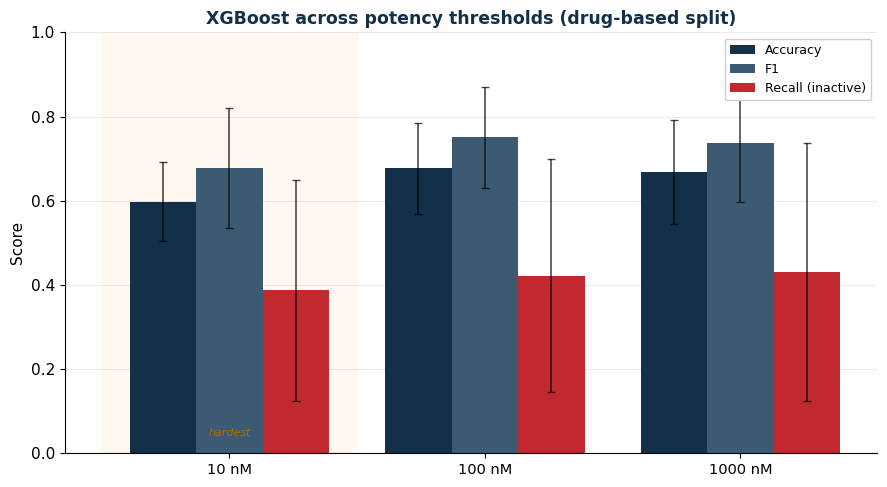

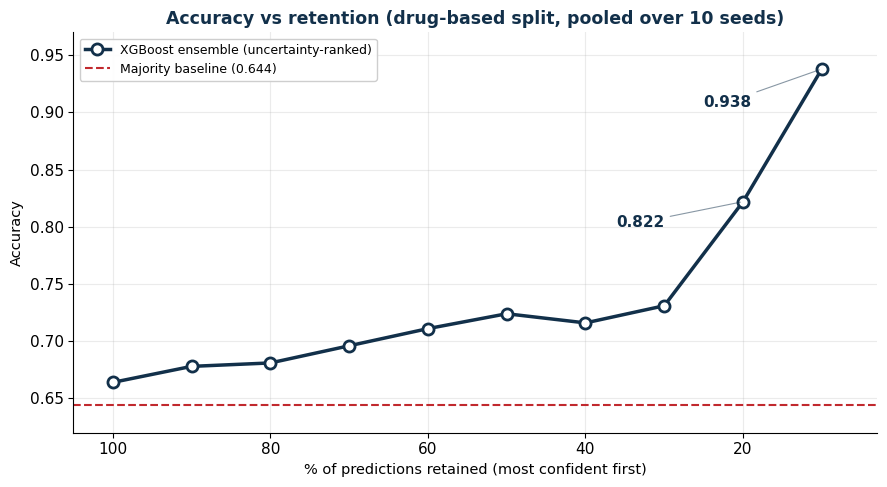

figure3_3.png, figure3_4.png 저장 완료 (색상 규약 일치), 최종!!!


In [6]:
# ============================================================
#  Figure 3.3, 3.4 색상 규약 일치 수정
#  규약: XGBoost=남색, GNN=청록, ADCNet=보라, 빨강=경고(낮은 recall)
#  → 3.3, 3.4는 모두 XGBoost 결과이므로 청록(GNN색) 대신 남색 계열 사용
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

XGB="#12304A"; RED="#C1292E"; GREY="#8A9BA5"
XGB_L="#3D5A73"   # XGBoost 보조색(남색 계열 밝은 톤) - F1용
plt.rcParams["font.size"]=11

# ---------- Figure 3.3 : threshold별 (남색 계열로 통일) ----------
thr=["10 nM","100 nM","1000 nM"]
acc=[0.598,0.677,0.668]; acc_e=[0.093,0.108,0.123]
f1=[0.678,0.751,0.738];  f1_e=[0.143,0.120,0.142]
rec=[0.387,0.422,0.431]; rec_e=[0.262,0.277,0.307]
x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(9,5))
ax.axvspan(-0.5,0.5,color="#FFF3E0",alpha=0.5,zorder=0)   # 10nM 강조(가장 어려움)
ax.text(0,0.04,"hardest",ha="center",fontsize=8,color="#B36A00",style="italic")
ax.bar(x-w,acc,w,yerr=acc_e,capsize=3,label="Accuracy",color=XGB,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x,  f1, w,yerr=f1_e, capsize=3,label="F1",color=XGB_L,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x+w,rec,w,yerr=rec_e,capsize=3,label="Recall (inactive)",color=RED,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.set_xticks(x); ax.set_xticklabels(thr,fontsize=10.5)
ax.set_ylabel("Score"); ax.set_ylim(0,1)
ax.set_title("XGBoost across potency thresholds (drug-based split)",fontsize=12.5,fontweight="bold",color=XGB)
ax.legend(fontsize=9,loc="upper right",framealpha=0.95)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_3.png",dpi=200,bbox_inches="tight"); plt.show()


# ---------- Figure 3.4 : retention (남색으로, teal 제거) ----------
ret=[100,90,80,70,60,50,40,30,20,10]
accr=[0.664,0.678,0.681,0.696,0.711,0.724,0.716,0.731,0.822,0.938]
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(ret,accr,"o-",color=XGB,lw=2.5,markersize=8,label="XGBoost ensemble (uncertainty-ranked)",
        markerfacecolor="white",markeredgewidth=2,markeredgecolor=XGB)
ax.axhline(0.644,ls="--",color=RED,lw=1.5,label="Majority baseline (0.644)")
ax.annotate("0.938",xy=(10,0.938),xytext=(22,0.905),fontsize=11,color=XGB,fontweight="bold",ha="center",
            arrowprops=dict(arrowstyle="-",color=XGB,lw=0.8,alpha=0.5))
ax.annotate("0.822",xy=(20,0.822),xytext=(33,0.800),fontsize=11,color=XGB,fontweight="bold",ha="center",
            arrowprops=dict(arrowstyle="-",color=XGB,lw=0.8,alpha=0.5))
ax.set_xlabel("% of predictions retained (most confident first)",fontsize=10.5)
ax.set_ylabel("Accuracy",fontsize=10.5)
ax.set_title("Accuracy vs retention (drug-based split, pooled over 10 seeds)",fontsize=12.5,fontweight="bold",color=XGB)
ax.invert_xaxis()
ax.legend(fontsize=9,loc="upper left",framealpha=0.95)
ax.grid(alpha=0.25); ax.set_axisbelow(True); ax.set_ylim(0.62,0.97)
ax.set_xlim(105,3); ax.set_xticks([100,80,60,40,20])
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_4.png",dpi=200,bbox_inches="tight"); plt.show()


print("figure3_3.png, figure3_4.png 저장 완료 (색상 규약 일치), 최종!!!")

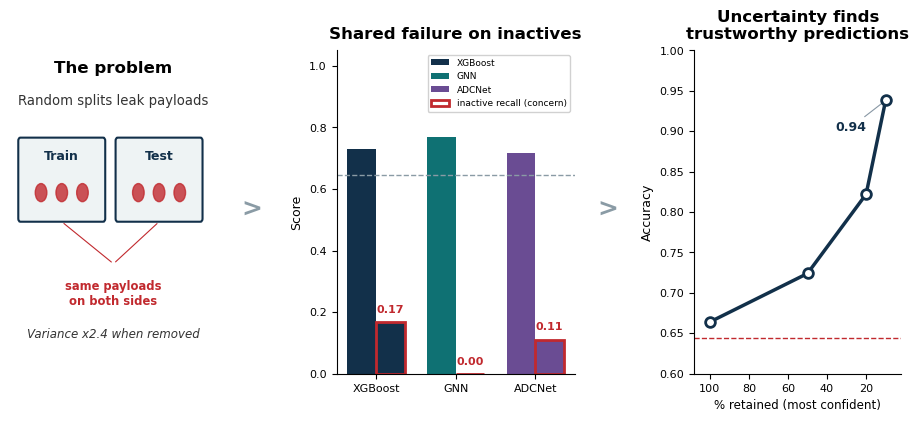

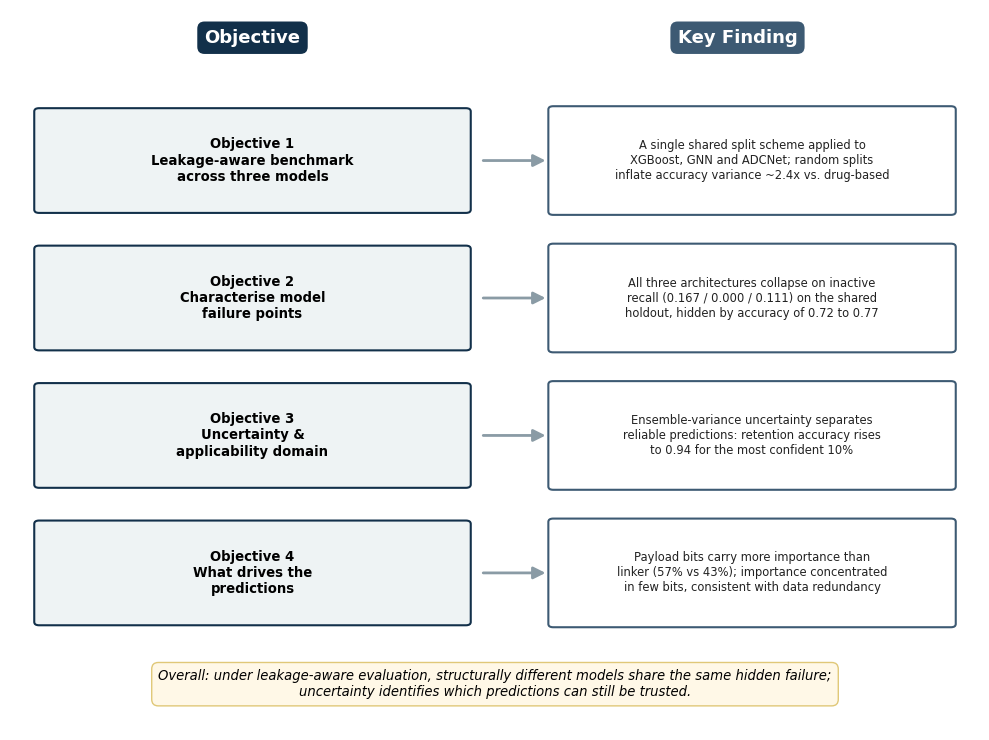

graphical_abstract.png, figure4_1.png 저장 완료, 최종


In [4]:
# ============================================================
#  그래픽 초록 + Figure 4.1 (목표-발견 요약)
#  색상 규약: XGBoost=남색, GNN=청록, ADCNet=보라, 빨강=경고(낮은 recall)
#  제목/텍스트=검정, 색상은 데이터 요소에만
#  Jupyter 새 셀에 붙여넣고 실행하세요.
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
import numpy as np
# ---- 논문 공통 색상 ----
XGB   = "#12304A"   # XGBoost = 남색
GNN   = "#0F7173"   # GNN     = 청록
ADC   = "#6A4C93"   # ADCNet  = 보라
SLATE = "#3D5A73"   # 보조 남색(다이어그램 강조용)
RED   = "#C1292E"   # 경고: 낮은 inactive recall
GREY  = "#8A9BA5"
LIGHT = "#EEF3F4"
BLACK = "#000000"   # 제목/라벨 텍스트
# ============================================================
#  (A) GRAPHICAL ABSTRACT  — 3단 스토리: 문제 → 공통실패 → 불확실성
# ============================================================
fig = plt.figure(figsize=(11.5, 4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.15, 1], wspace=0.55)  # wspace 넓혀 화살표 공간 확보
# --- Panel 1: 문제(leakage) ---
ax1 = fig.add_subplot(gs[0]); ax1.set_xlim(0,10); ax1.set_ylim(0,10); ax1.axis("off")
ax1.text(5, 9.3, "The problem", ha="center", fontsize=12, fontweight="bold", color=BLACK)
ax1.text(5, 8.3, "Random splits leak payloads", ha="center", fontsize=9.5, color="#333")
ax1.add_patch(FancyBboxPatch((0.5,4.8),4,2.4, boxstyle="round,pad=0.1", facecolor=LIGHT, edgecolor=XGB, lw=1.5))
ax1.add_patch(FancyBboxPatch((5.2,4.8),4,2.4, boxstyle="round,pad=0.1", facecolor=LIGHT, edgecolor=XGB, lw=1.5))
ax1.text(2.5, 6.6, "Train", ha="center", fontsize=9, fontweight="bold", color=XGB)
ax1.text(7.2, 6.6, "Test",  ha="center", fontsize=9, fontweight="bold", color=XGB)
for x in [1.5,2.5,3.5]: ax1.add_patch(plt.Circle((x,5.6),0.28, color=RED, alpha=0.8))
for x in [6.2,7.2,8.2]: ax1.add_patch(plt.Circle((x,5.6),0.28, color=RED, alpha=0.8))
# 빨간 선: Train·Test 양쪽 대칭으로 (가운데 라벨에서 양쪽 박스로 갈래 연결)
ax1.annotate("", xy=(2.5,4.7), xytext=(5,3.4), arrowprops=dict(arrowstyle="-", color=RED, lw=0.8))
ax1.annotate("", xy=(7.2,4.7), xytext=(5,3.4), arrowprops=dict(arrowstyle="-", color=RED, lw=0.8))
ax1.text(5, 2.9, "same payloads\non both sides", ha="center", va="top",
         fontsize=8.3, color=RED, fontweight="bold")
ax1.text(5, 1.1, "Variance x2.4 when removed", ha="center", fontsize=8.5, color="#333", style="italic")
# --- Panel 2: 세 모델 공통 실패 (모델별 색 + recall 빨간테두리) ---
ax2 = fig.add_subplot(gs[1])
models=["XGBoost","GNN","ADCNet"]; mcol=[XGB,GNN,ADC]
acc=[0.731,0.769,0.718]; rec=[0.167,0.000,0.111]
x=np.arange(3); w=0.36
for i,(v,c) in enumerate(zip(acc,mcol)): ax2.bar(i-w/2, v, w, color=c)
for i,(v,c) in enumerate(zip(rec,mcol)):
    ax2.bar(i+w/2, v, w, color=c, edgecolor=RED, linewidth=2)
    ax2.text(i+w/2, v+0.03, f"{v:.2f}", ha="center", fontsize=8, color=RED, fontweight="bold")
ax2.axhline(0.644, ls="--", color=GREY, lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=8.5)
ax2.set_ylim(0,1.05); ax2.set_ylabel("Score", fontsize=9); ax2.tick_params(labelsize=8)
ax2.set_title("Shared failure on inactives", fontsize=12, fontweight="bold", color=BLACK, pad=8)
leg=[Patch(facecolor=XGB,label="XGBoost"), Patch(facecolor=GNN,label="GNN"),
     Patch(facecolor=ADC,label="ADCNet"),
     Patch(facecolor="white",edgecolor=RED,linewidth=2,label="inactive recall (concern)")]
ax2.legend(handles=leg, fontsize=6.5, loc="upper right", framealpha=0.9)
ax2.spines[["top","right"]].set_visible(False)
# --- Panel 3: 불확실성 → 신뢰 예측 (남색) ---
ax3 = fig.add_subplot(gs[2])
ret=[100,50,20,10]; accr=[0.664,0.724,0.822,0.938]
ax3.plot(ret, accr, "o-", color=XGB, lw=2.5, markersize=7,
         markerfacecolor="white", markeredgewidth=2, markeredgecolor=XGB)
ax3.axhline(0.644, ls="--", color=RED, lw=1)
# "0.94" 라벨: 점에서 떨어뜨려 화살표로 연결 (겹침 해결)
ax3.annotate("0.94", xy=(10,0.938), xytext=(28,0.90),
             fontsize=9, color=XGB, fontweight="bold", ha="center",
             arrowprops=dict(arrowstyle="-", color=XGB, lw=0.8, alpha=0.5))
ax3.invert_xaxis()
ax3.set_title("Uncertainty finds\ntrustworthy predictions", fontsize=12, fontweight="bold", color=BLACK, pad=8)
ax3.set_xlabel("% retained (most confident)", fontsize=8.5); ax3.set_ylabel("Accuracy", fontsize=9)
ax3.tick_params(labelsize=8); ax3.set_ylim(0.6,1.0); ax3.set_xlim(108, 2)
ax3.spines[["top","right"]].set_visible(False)
# 패널 사이 화살표: 축·글자와 안 겹치도록 위치 조정 + 연한 색
fig.text(0.335, 0.5, ">", fontsize=18, color=GREY, ha="center", va="center", fontweight="bold")
fig.text(0.645, 0.5, ">", fontsize=18, color=GREY, ha="center", va="center", fontweight="bold")
plt.savefig("graphical_abstract.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
# ============================================================
#  (B) FIGURE 4.1  — Objective vs Key Finding 정렬 (em dash 없음)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.set_xlim(0,10); ax.set_ylim(0,11); ax.axis("off")
ax.text(2.5, 10.5, "Objective", ha="center", fontsize=13, fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=XGB, edgecolor="none"))
ax.text(7.5, 10.5, "Key Finding", ha="center", fontsize=13, fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=SLATE, edgecolor="none"))
rows = [
 ("Objective 1\nLeakage-aware benchmark\nacross three models",
  "A single shared split scheme applied to\nXGBoost, GNN and ADCNet; random splits\ninflate accuracy variance ~2.4x vs. drug-based"),
 ("Objective 2\nCharacterise model\nfailure points",
  "All three architectures collapse on inactive\nrecall (0.167 / 0.000 / 0.111) on the shared\nholdout, hidden by accuracy of 0.72 to 0.77"),
 ("Objective 3\nUncertainty &\napplicability domain",
  "Ensemble-variance uncertainty separates\nreliable predictions: retention accuracy rises\nto 0.94 for the most confident 10%"),
 ("Objective 4\nWhat drives the\npredictions",
  "Payload bits carry more importance than\nlinker (57% vs 43%); importance concentrated\nin few bits, consistent with data redundancy"),
]
for (obj, find), y in zip(rows, [8.7,6.6,4.5,2.4]):
    ax.add_patch(FancyBboxPatch((0.3,y-0.75),4.4,1.5, boxstyle="round,pad=0.05",
                                facecolor=LIGHT, edgecolor=XGB, lw=1.5))
    ax.text(2.5, y, obj, ha="center", va="center", fontsize=9.5, color=BLACK, fontweight="bold")
    ax.add_patch(FancyArrowPatch((4.85,y),(5.55,y), arrowstyle="-|>", mutation_scale=18, color=GREY, lw=2))
    ax.add_patch(FancyBboxPatch((5.6,y-0.78),4.1,1.56, boxstyle="round,pad=0.05",
                                facecolor="white", edgecolor=SLATE, lw=1.5))
    ax.text(7.65, y, find, ha="center", va="center", fontsize=8.3, color="#222222")
ax.text(5, 0.7,
        "Overall: under leakage-aware evaluation, structurally different models share the same hidden failure;\n"
        "uncertainty identifies which predictions can still be trusted.",
        ha="center", va="center", fontsize=9.5, color=BLACK, style="italic",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8E7", edgecolor="#E0C878"))
plt.tight_layout()
plt.savefig("figure4_1.png", dpi=200, bbox_inches="tight")
plt.show()
print("graphical_abstract.png, figure4_1.png 저장 완료, 최종!!!")

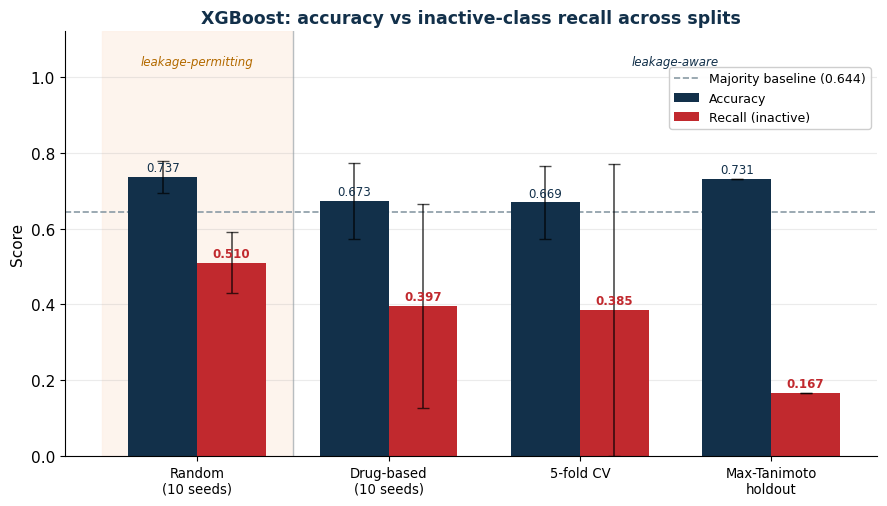

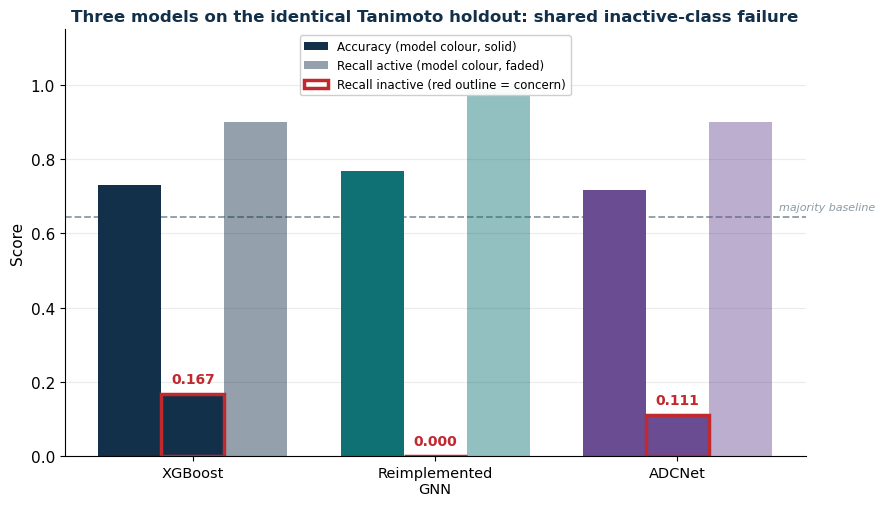

figure3_1.png, figure3_2.png 저장 완료


In [7]:
# ============================================================
#  ADC 논문 그래프 개선 코드 (모델별 고정색 + leakage 구분 음영)
#  Jupyter 새 셀에 붙여넣고 실행하세요.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---- 논문 전체 공통 색상 체계 (모든 그래프에서 동일하게 사용) ----
XGB  = "#12304A"   # XGBoost = 남색
GNN  = "#0F7173"   # GNN     = 청록
ADC  = "#6A4C93"   # ADCNet  = 보라
RED  = "#C1292E"   # 경고: leakage-aware 평가에서 드러난 낮은 recall(inactive)
GREY = "#8A9BA5"
plt.rcParams["font.size"] = 11

# ============================================================
# Figure 3.1 : XGBoost split별 (Random=leakage / 나머지=leakage-aware 음영 구분)
# ============================================================
splits=["Random\n(10 seeds)","Drug-based\n(10 seeds)","5-fold CV","Max-Tanimoto\nholdout"]
acc=[0.737,0.673,0.669,0.731]; acc_err=[0.042,0.101,0.097,0]
rec=[0.510,0.397,0.385,0.167]; rec_err=[0.080,0.269,0.386,0]
x=np.arange(4); w=0.36
fig,ax=plt.subplots(figsize=(9,5.2))
ax.axvspan(-0.5,0.5,color="#FDF0E6",alpha=0.7,zorder=0)      # Random 배경 음영
ax.axvline(0.5,ls="-",color=GREY,lw=1,alpha=0.6,zorder=1)     # 구분선
ax.text(0,1.03,"leakage-permitting",ha="center",fontsize=8.5,color="#B36A00",style="italic")
ax.text(2.5,1.03,"leakage-aware",ha="center",fontsize=8.5,color=XGB,style="italic")
ax.bar(x-w/2,acc,w,yerr=acc_err,capsize=4,label="Accuracy",color=XGB,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x+w/2,rec,w,yerr=rec_err,capsize=4,label="Recall (inactive)",color=RED,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.axhline(0.644,ls="--",color=GREY,lw=1.2,label="Majority baseline (0.644)",zorder=0)
for i,v in enumerate(acc): ax.text(i-w/2,v+0.015,f"{v:.3f}",ha="center",fontsize=8.5,color=XGB)
for i,v in enumerate(rec): ax.text(i+w/2,v+0.015,f"{v:.3f}",ha="center",fontsize=8.5,color=RED,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(splits,fontsize=9.5)
ax.set_ylabel("Score"); ax.set_ylim(0,1.12)
ax.set_title("XGBoost: accuracy vs inactive-class recall across splits",fontsize=12.5,fontweight="bold",color=XGB)
ax.legend(fontsize=9,loc="upper right",framealpha=0.95,bbox_to_anchor=(1.0,0.93))
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_1.png",dpi=200,bbox_inches="tight"); plt.show()

# ============================================================
# Figure 3.2 : 세 모델 cross-holdout (모델별 고정색 + recall inactive 빨간 테두리)
# ============================================================
models=["XGBoost","Reimplemented\nGNN","ADCNet"]; mcol=[XGB,GNN,ADC]
acc=[0.731,0.769,0.718]; rec_in=[0.167,0.000,0.111]; rec_ac=[0.900,1.000,0.900]
x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(9,5.2))
for i,(v,c) in enumerate(zip(acc,mcol)):    ax.bar(i-w,v,w,color=c)                       # Accuracy=진한 모델색
for i,(v,c) in enumerate(zip(rec_ac,mcol)): ax.bar(i+w,v,w,color=c,alpha=0.45)             # Recall active=연한 모델색
for i,(v,c) in enumerate(zip(rec_in,mcol)):                                                 # Recall inactive=빨간테두리(경고)
    ax.bar(i,v,w,color=c,edgecolor=RED,linewidth=2.5)
    ax.text(i,v+0.03,f"{v:.3f}",ha="center",fontsize=10,color=RED,fontweight="bold")
ax.axhline(0.644,ls="--",color=GREY,lw=1.3,zorder=0)
ax.text(2.42,0.664,"majority baseline",fontsize=8,color=GREY,style="italic")
leg=[Patch(facecolor=XGB,label="Accuracy (model colour, solid)"),
     Patch(facecolor=XGB,alpha=0.45,label="Recall active (model colour, faded)"),
     Patch(facecolor="white",edgecolor=RED,linewidth=2.5,label="Recall inactive (red outline = concern)")]
ax.legend(handles=leg,fontsize=8.5,loc="upper center",framealpha=0.95)
ax.set_xticks(x); ax.set_xticklabels(models,fontsize=10.5)
ax.set_ylabel("Score"); ax.set_ylim(0,1.15)
ax.set_title("Three models on the identical Tanimoto holdout: shared inactive-class failure",
             fontsize=12,fontweight="bold",color=XGB)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_2.png",dpi=200,bbox_inches="tight"); plt.show()

print("figure3_1.png, figure3_2.png 저장 완료")

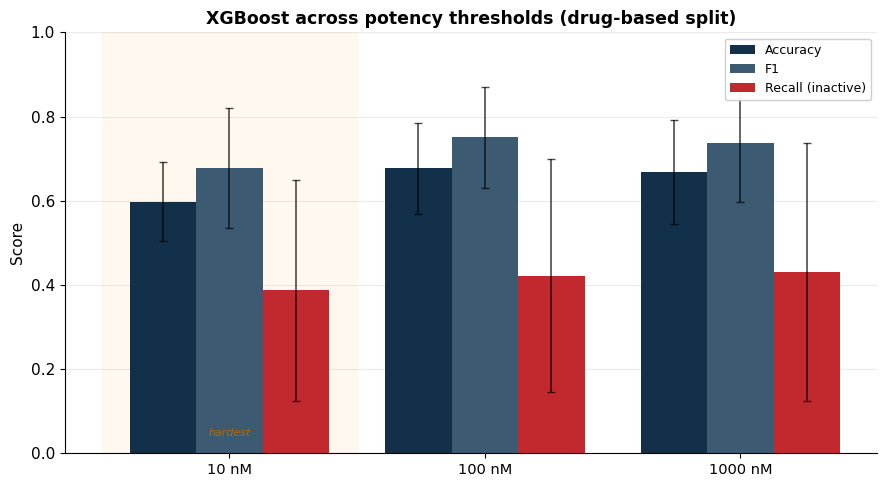

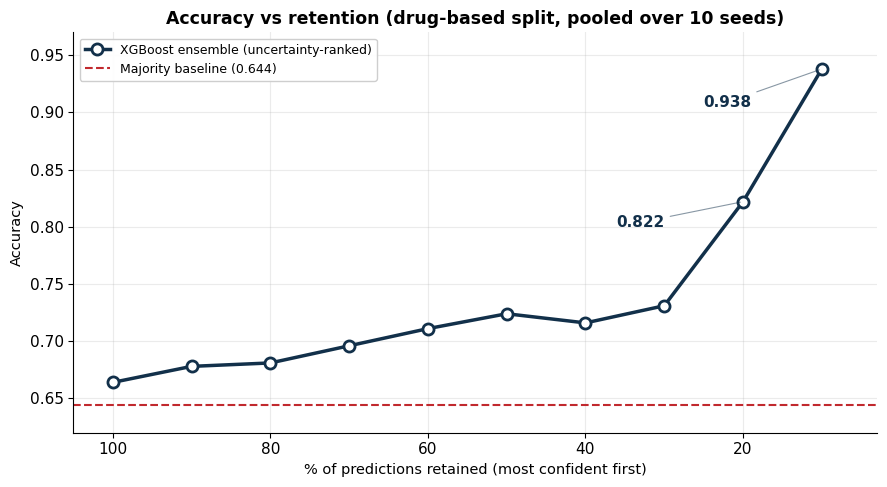

figure3_3.png, figure3_4.png 저장 완료 (제목 검정), 최종!!!


In [8]:
# ============================================================
#  Figure 3.3, 3.4 색상 규약 일치 수정
#  규약: XGBoost=남색, GNN=청록, ADCNet=보라, 빨강=경고(낮은 recall)
#  제목=검정, 데이터 요소만 색상
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
XGB="#12304A"; RED="#C1292E"; GREY="#8A9BA5"
XGB_L="#3D5A73"   # XGBoost 보조색(남색 계열 밝은 톤) - F1용
BLACK="#000000"
plt.rcParams["font.size"]=11
# ---------- Figure 3.3 : threshold별 (남색 계열로 통일) ----------
thr=["10 nM","100 nM","1000 nM"]
acc=[0.598,0.677,0.668]; acc_e=[0.093,0.108,0.123]
f1=[0.678,0.751,0.738];  f1_e=[0.143,0.120,0.142]
rec=[0.387,0.422,0.431]; rec_e=[0.262,0.277,0.307]
x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(9,5))
ax.axvspan(-0.5,0.5,color="#FFF3E0",alpha=0.5,zorder=0)   # 10nM 강조(가장 어려움)
ax.text(0,0.04,"hardest",ha="center",fontsize=8,color="#B36A00",style="italic")
ax.bar(x-w,acc,w,yerr=acc_e,capsize=3,label="Accuracy",color=XGB,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x,  f1, w,yerr=f1_e, capsize=3,label="F1",color=XGB_L,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x+w,rec,w,yerr=rec_e,capsize=3,label="Recall (inactive)",color=RED,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.set_xticks(x); ax.set_xticklabels(thr,fontsize=10.5)
ax.set_ylabel("Score"); ax.set_ylim(0,1)
ax.set_title("XGBoost across potency thresholds (drug-based split)",fontsize=12.5,fontweight="bold",color=BLACK)
ax.legend(fontsize=9,loc="upper right",framealpha=0.95)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_3.png",dpi=200,bbox_inches="tight"); plt.show()
# ---------- Figure 3.4 : retention (남색으로, teal 제거) ----------
ret=[100,90,80,70,60,50,40,30,20,10]
accr=[0.664,0.678,0.681,0.696,0.711,0.724,0.716,0.731,0.822,0.938]
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(ret,accr,"o-",color=XGB,lw=2.5,markersize=8,label="XGBoost ensemble (uncertainty-ranked)",
        markerfacecolor="white",markeredgewidth=2,markeredgecolor=XGB)
ax.axhline(0.644,ls="--",color=RED,lw=1.5,label="Majority baseline (0.644)")
ax.annotate("0.938",xy=(10,0.938),xytext=(22,0.905),fontsize=11,color=XGB,fontweight="bold",ha="center",
            arrowprops=dict(arrowstyle="-",color=XGB,lw=0.8,alpha=0.5))
ax.annotate("0.822",xy=(20,0.822),xytext=(33,0.800),fontsize=11,color=XGB,fontweight="bold",ha="center",
            arrowprops=dict(arrowstyle="-",color=XGB,lw=0.8,alpha=0.5))
ax.set_xlabel("% of predictions retained (most confident first)",fontsize=10.5)
ax.set_ylabel("Accuracy",fontsize=10.5)
ax.set_title("Accuracy vs retention (drug-based split, pooled over 10 seeds)",fontsize=12.5,fontweight="bold",color=BLACK)
ax.invert_xaxis()
ax.legend(fontsize=9,loc="upper left",framealpha=0.95)
ax.grid(alpha=0.25); ax.set_axisbelow(True); ax.set_ylim(0.62,0.97)
ax.set_xlim(105,3); ax.set_xticks([100,80,60,40,20])
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_4.png",dpi=200,bbox_inches="tight"); plt.show()
print("figure3_3.png, figure3_4.png 저장 완료 (제목 검정), 최종!!!")

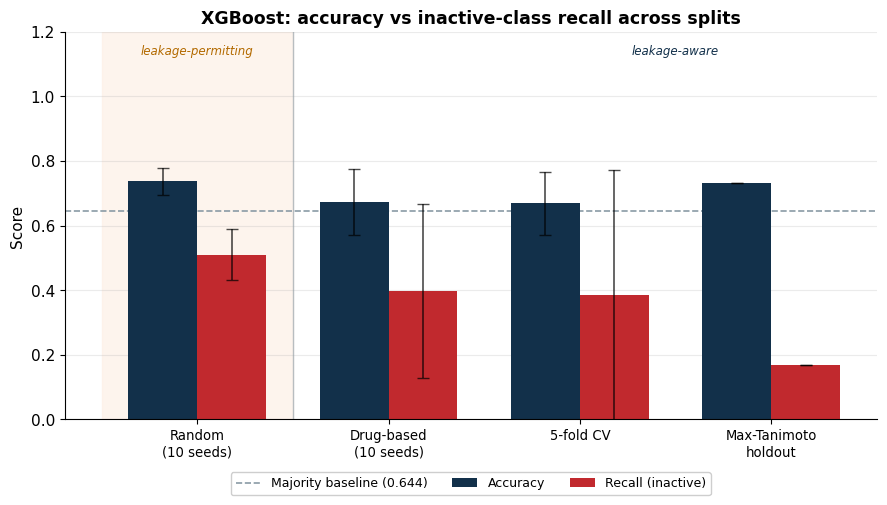

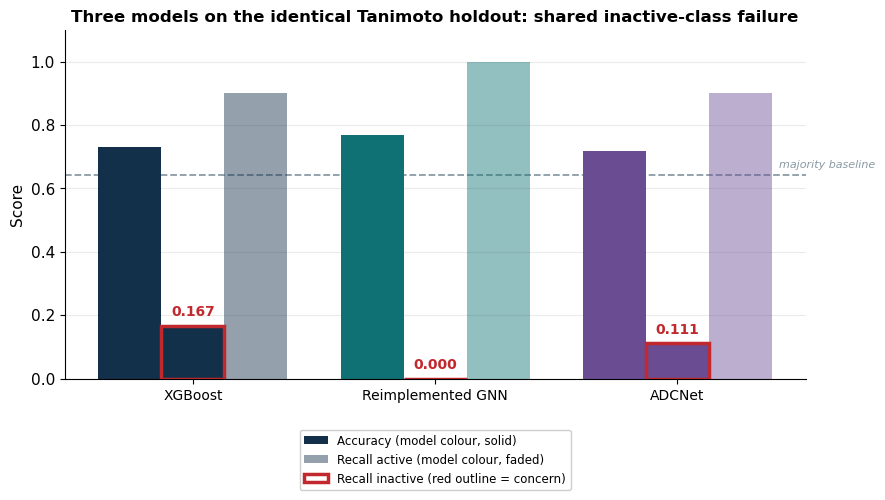

figure3_2.png 저장 완료 (제목 검정, 범례 아래)


In [11]:
# ============================================================
#  ADC 논문 그래프 개선 코드 (모델별 고정색 + leakage 구분 음영)
#  제목=검정, 데이터 요소만 색상 / Figure 3.1 겹침 해결
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
# ---- 논문 전체 공통 색상 체계 ----
XGB  = "#12304A"   # XGBoost = 남색
GNN  = "#0F7173"   # GNN     = 청록
ADC  = "#6A4C93"   # ADCNet  = 보라
RED  = "#C1292E"   # 경고: 낮은 recall(inactive)
GREY = "#8A9BA5"
BLACK= "#000000"
plt.rcParams["font.size"] = 11
# ============================================================
# Figure 3.1 : XGBoost split별
# ============================================================
splits=["Random\n(10 seeds)","Drug-based\n(10 seeds)","5-fold CV","Max-Tanimoto\nholdout"]
acc=[0.737,0.673,0.669,0.731]; acc_err=[0.042,0.101,0.097,0]
rec=[0.510,0.397,0.385,0.167]; rec_err=[0.080,0.269,0.386,0]
x=np.arange(4); w=0.36
fig,ax=plt.subplots(figsize=(9,5.2))
ax.set_ylim(0,1.20)                                          # 상단 여유 확보
ax.axvspan(-0.5,0.5,color="#FDF0E6",alpha=0.7,zorder=0)      # Random 배경 음영
ax.axvline(0.5,ls="-",color=GREY,lw=1,alpha=0.6,zorder=1)    # 구분선
# leakage 라벨을 막대보다 훨씬 위(1.13)에 두어 범례/막대와 분리
ax.text(0,1.13,"leakage-permitting",ha="center",fontsize=8.5,color="#B36A00",style="italic")
ax.text(2.5,1.13,"leakage-aware",ha="center",fontsize=8.5,color=XGB,style="italic")
ax.bar(x-w/2,acc,w,yerr=acc_err,capsize=4,label="Accuracy",color=XGB,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.bar(x+w/2,rec,w,yerr=rec_err,capsize=4,label="Recall (inactive)",color=RED,error_kw={"elinewidth":1.2,"alpha":0.7})
ax.axhline(0.644,ls="--",color=GREY,lw=1.2,label="Majority baseline (0.644)",zorder=0)
# 수치 라벨 제거 (정확한 값은 Table 3.1에 있음, 에러바 겹침 방지)
ax.set_xticks(x); ax.set_xticklabels(splits,fontsize=9.5)
ax.set_ylabel("Score")
ax.set_title("XGBoost: accuracy vs inactive-class recall across splits",fontsize=12.5,fontweight="bold",color=BLACK)
# 범례를 그래프 밖(하단)으로 빼서 leakage 라벨과 겹침 방지
ax.legend(fontsize=9,loc="upper center",bbox_to_anchor=(0.5,-0.12),ncol=3,framealpha=0.95)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_1.png",dpi=200,bbox_inches="tight"); plt.show()
# ============================================================
# Figure 3.2 : 세 모델 cross-holdout
# ============================================================
# ============================================================
#  Figure 3.2 : 세 모델 cross-holdout
#  제목=검정, 범례=그래프 아래(3.1과 일관), GNN 라벨 명확화
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
XGB  = "#12304A"   # XGBoost = 남색
GNN  = "#0F7173"   # GNN     = 청록
ADC  = "#6A4C93"   # ADCNet  = 보라
RED  = "#C1292E"   # 경고: 낮은 recall(inactive)
GREY = "#8A9BA5"
BLACK= "#000000"
plt.rcParams["font.size"] = 11
models=["XGBoost","Reimplemented GNN","ADCNet"]; mcol=[XGB,GNN,ADC]
acc=[0.731,0.769,0.718]; rec_in=[0.167,0.000,0.111]; rec_ac=[0.900,1.000,0.900]
x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(9,5.2))
for i,(v,c) in enumerate(zip(acc,mcol)):
    ax.bar(i-w,v,w,color=c)                       # Accuracy=진한 모델색
for i,(v,c) in enumerate(zip(rec_ac,mcol)):
    ax.bar(i+w,v,w,color=c,alpha=0.45)            # Recall active=연한 모델색
for i,(v,c) in enumerate(zip(rec_in,mcol)):       # Recall inactive=빨간테두리(경고)
    ax.bar(i,v,w,color=c,edgecolor=RED,linewidth=2.5)
    ax.text(i,v+0.03,f"{v:.3f}",ha="center",fontsize=10,color=RED,fontweight="bold")
ax.axhline(0.644,ls="--",color=GREY,lw=1.3,zorder=0)
ax.text(2.42,0.664,"majority baseline",fontsize=8,color=GREY,style="italic")
leg=[Patch(facecolor=XGB,label="Accuracy (model colour, solid)"),
     Patch(facecolor=XGB,alpha=0.45,label="Recall active (model colour, faded)"),
     Patch(facecolor="white",edgecolor=RED,linewidth=2.5,label="Recall inactive (red outline = concern)")]
ax.set_xticks(x); ax.set_xticklabels(models,fontsize=10)
ax.set_ylabel("Score"); ax.set_ylim(0,1.10)
ax.set_title("Three models on the identical Tanimoto holdout: shared inactive-class failure",
             fontsize=12,fontweight="bold",color=BLACK)
# 범례를 그래프 아래로 (3.1과 일관, 막대와 안 겹침)
ax.legend(handles=leg,fontsize=8.5,loc="upper center",
          bbox_to_anchor=(0.5,-0.13),ncol=1,framealpha=0.95)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("figure3_2.png",dpi=200,bbox_inches="tight"); plt.show()
print("figure3_2.png 저장 완료 (제목 검정, 범례 아래)")

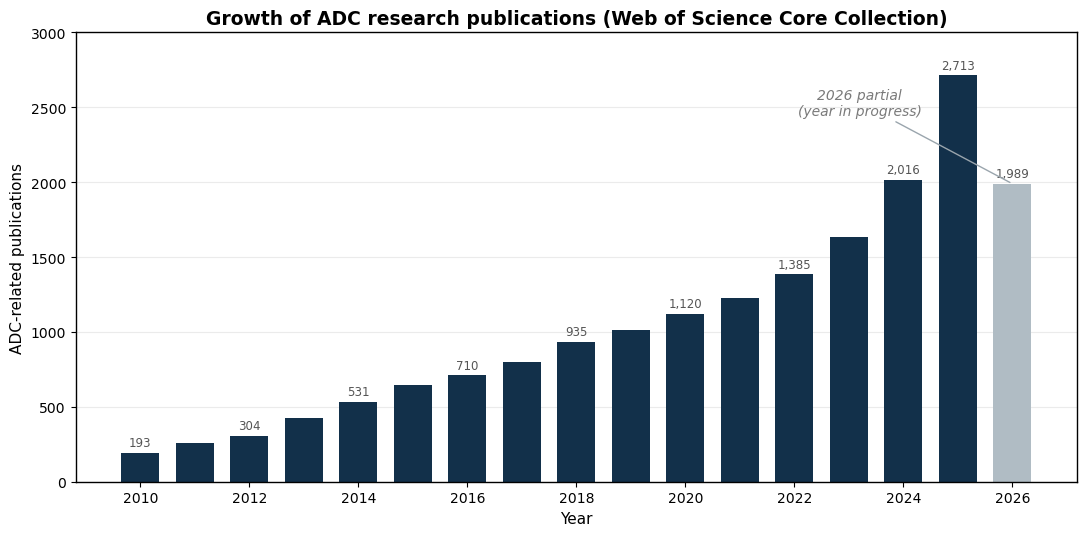

In [13]:
import matplotlib.pyplot as plt
NAVY="#12304A"; GREY="#B0BCC4"; BLACK="#000000"
data={2010:193,2011:258,2012:304,2013:425,2014:531,2015:647,2016:710,
      2017:797,2018:935,2019:1016,2020:1120,2021:1226,2022:1385,2023:1634,
      2024:2016,2025:2713,2026:1989}
years=list(data.keys()); counts=list(data.values())
fig,ax=plt.subplots(figsize=(11,5.5))
colors=[GREY if y==2026 else NAVY for y in years]
ax.bar(years,counts,color=colors,width=0.7)
label_years={2010,2012,2014,2016,2018,2020,2022,2024,2025,2026}
for y,c in data.items():
    if y in label_years:
        ax.text(y,c+45,f"{c:,}",ha="center",fontsize=8.5,color="#555555")
ax.annotate("2026 partial\n(year in progress)", xy=(2026,1989), xytext=(2023.2,2450),
            fontsize=10,color="#7A7A7A",style="italic",ha="center",
            arrowprops=dict(arrowstyle="-",color="#9AA5AD",lw=1))
ax.set_xlabel("Year",fontsize=11,color=BLACK)
ax.set_ylabel("ADC-related publications",fontsize=11,color=BLACK)
ax.set_title("Growth of ADC research publications (Web of Science Core Collection)",
             fontsize=13.5,fontweight="bold",color=BLACK)
ax.set_ylim(0,3000)
ax.set_xticks([2010,2012,2014,2016,2018,2020,2022,2024,2026])
ax.tick_params(labelsize=10)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
for s in ax.spines.values():
    s.set_visible(True)
    s.set_color("black")
    s.set_linewidth(1)
plt.tight_layout(); plt.savefig("figure1_1.png",dpi=200,bbox_inches="tight"); plt.show()